In [1]:
import pandas as pd
import numpy as np

# UCI Adult dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    url,
    names=columns,
    na_values="?",
    skipinitialspace=True
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

Dataset loaded successfully!
Shape: (32561, 15)

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']

First 5 rows:


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



Missing values:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


In [4]:
# Step 2: Data Preprocessing

# Remove leading/trailing spaces from categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].str.strip()

# Handle missing values
# Replace missing categorical values with the most frequent value
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Convert target variable to binary
# <=50K = 0, >50K = 1
df["income"] = df["income"].apply(
    lambda x: 1 if x == ">50K" else 0
)

# Check preprocessing
print("Missing values after preprocessing:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["income"].value_counts())

print("\nDataset shape after preprocessing:")
print(df.shape)

Missing values after preprocessing:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Target distribution:
income
0    24720
1     7841
Name: count, dtype: int64

Dataset shape after preprocessing:
(32561, 15)


In [6]:
# Step 3: Separate features and target

X = df.drop("income", axis=1)
y = df["income"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Identify categorical and numerical columns
categorical_columns = X.select_dtypes(include="object").columns.tolist()
numerical_columns = X.select_dtypes(exclude="object").columns.tolist()

print("\nCategorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Features shape: (32561, 14)
Target shape: (32561,)

Categorical columns:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

Numerical columns:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


In [8]:
# Step 4: Encode categorical variables

# Convert categorical variables into numerical dummy variables
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

# Convert boolean columns to integers
X_encoded = X_encoded.astype(float)

print("Original feature shape:", X.shape)
print("Encoded feature shape:", X_encoded.shape)

print("\nFirst 5 rows of encoded data:")
display(X_encoded.head())

Original feature shape: (32561, 14)
Encoded feature shape: (32561, 97)

First 5 rows of encoded data:


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
0,39.0,77516.0,13.0,2174.0,0.0,40.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,50.0,83311.0,13.0,0.0,0.0,13.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,38.0,215646.0,9.0,0.0,0.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,53.0,234721.0,7.0,0.0,0.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,28.0,338409.0,13.0,0.0,0.0,40.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# Step 5: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (26048, 97)
Testing set shape: (6513, 97)

Training target distribution:
income
0    19775
1     6273
Name: count, dtype: int64

Testing target distribution:
income
0    4945
1    1568
Name: count, dtype: int64


In [13]:
# Step 6: Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print("\nTraining data mean (approximately):", X_train_scaled.mean())
print("Training data standard deviation (approximately):", X_train_scaled.std())

Scaled training shape: (26048, 97)
Scaled testing shape: (6513, 97)

Training data mean (approximately): -1.743555498537443e-19
Training data standard deviation (approximately): 0.9999999999999997


In [15]:
# Step 7: Train Classification Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

print("Training classification models...\n")

# 1. Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
logistic_model.fit(X_train_scaled, y_train)

# 2. Decision Tree
decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)
decision_tree_model.fit(X_train_scaled, y_train)

# 3. K-Nearest Neighbors
knn_model = KNeighborsClassifier(
    n_neighbors=5
)
knn_model.fit(X_train_scaled, y_train)

# 4. Gaussian Naive Bayes
naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train_scaled, y_train)

# 5. Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=12,
    n_jobs=-1
)
random_forest_model.fit(X_train_scaled, y_train)

print("✓ Logistic Regression trained")
print("✓ Decision Tree trained")
print("✓ KNN trained")
print("✓ Naive Bayes trained")
print("✓ Random Forest trained")
print("\n✓ All 5 models trained successfully!")

Training classification models...

✓ Logistic Regression trained
✓ Decision Tree trained
✓ KNN trained
✓ Naive Bayes trained
✓ Random Forest trained

✓ All 5 models trained successfully!


In [17]:
# Step 8: Evaluate all models

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "KNN": knn_model,
    "Naive Bayes": naive_bayes_model,
    "Random Forest": random_forest_model
}

results = []

for model_name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Probability predictions for AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "MCC": mcc
    })

# Create comparison table
results_df = pd.DataFrame(results)

print("Model Evaluation Results:")
display(results_df.round(4))

Model Evaluation Results:


,Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.8549,0.9074,0.7376,0.6167,0.6718,0.5834
1,Decision Tree,0.8567,0.9006,0.7222,0.6582,0.6887,0.5970
2,KNN,0.8263,0.8498,0.6557,0.5867,0.6193,0.5086
3,Naive Bayes,0.4167,0.6830,0.2889,0.9732,0.4455,0.2332
4,Random Forest,0.8617,0.9166,0.7986,0.5689,0.6644,0.5936


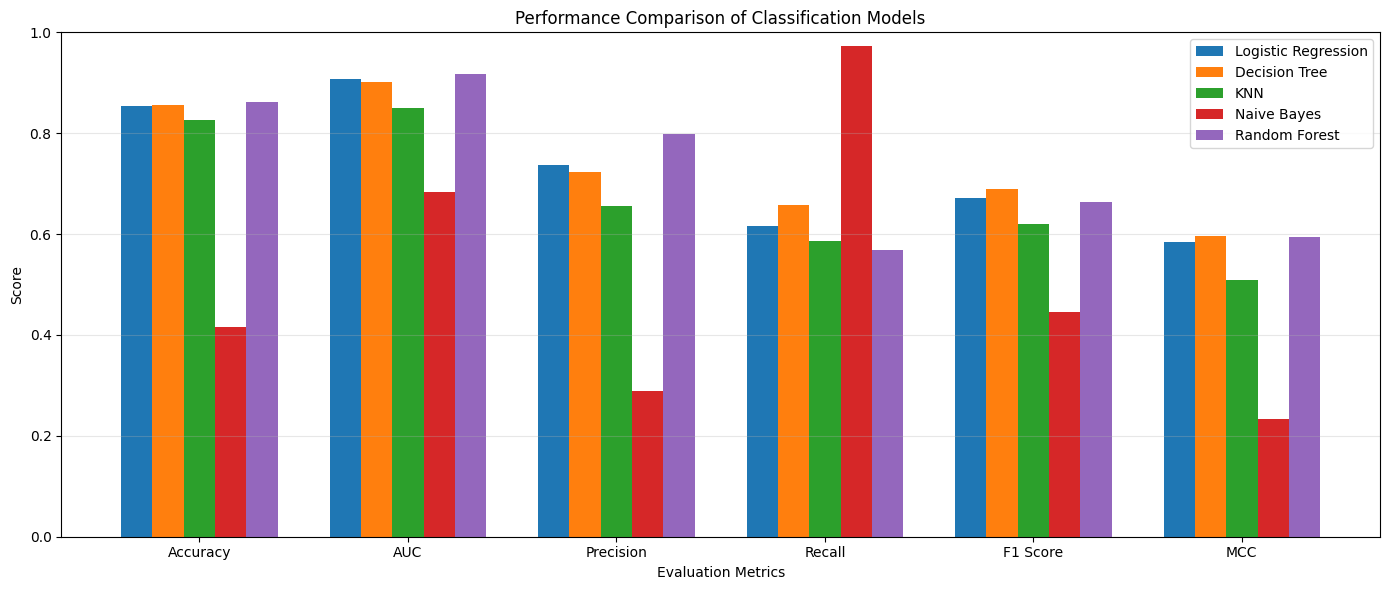

In [19]:
# Step 9: Model Performance Comparison

import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "Accuracy",
    "AUC",
    "Precision",
    "Recall",
    "F1 Score",
    "MCC"
]

x = np.arange(len(metrics))
width = 0.15

plt.figure(figsize=(14, 6))

for i, row in results_df.iterrows():
    values = [row[m] for m in metrics]
    plt.bar(
        x + (i - 2) * width,
        values,
        width,
        label=row["Model"]
    )

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Performance Comparison of Classification Models")
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

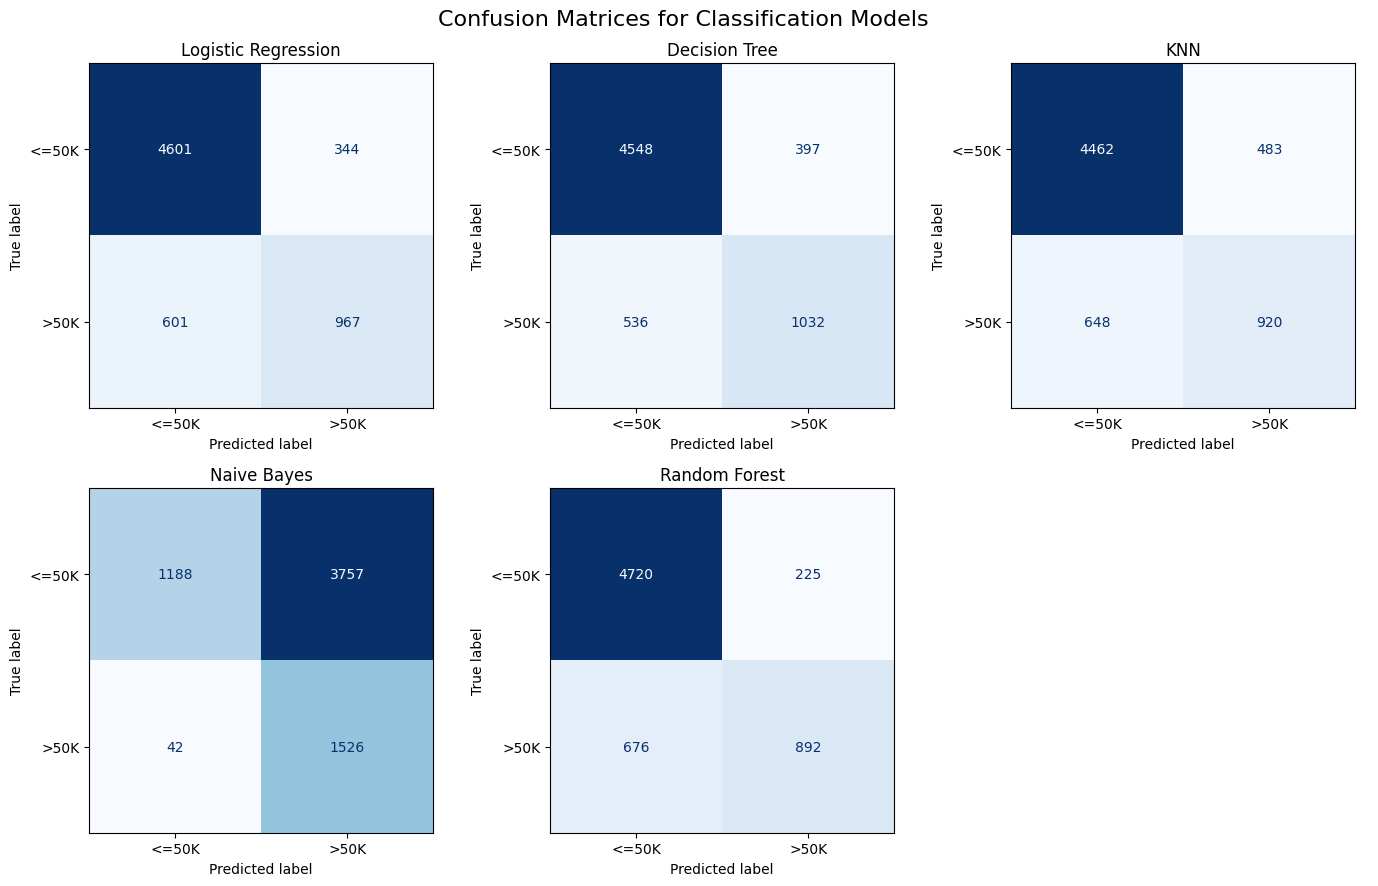

In [21]:
# Step 10: Confusion Matrices

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

for i, (model_name, model) in enumerate(models.items()):
    
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["<=50K", ">50K"]
    )
    
    disp.plot(
        ax=axes[i],
        cmap="Blues",
        colorbar=False
    )
    
    axes[i].set_title(model_name)

# Hide unused sixth subplot
axes[-1].axis("off")

plt.suptitle("Confusion Matrices for Classification Models", fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
# Step 11: Model-wise Observations

observations = {
    "Logistic Regression": """
Logistic Regression achieved an accuracy of 85.49% and an AUC of 90.74%.
Its precision was 73.76%, recall was 61.67%, and F1 score was 67.18%.
The MCC value of 58.34% indicates a reasonably good correlation between
the predicted and actual classes. The model provides a strong baseline
and performs consistently across the evaluation metrics.
""",

    "Decision Tree": """
Decision Tree achieved an accuracy of 85.67% and an AUC of 90.06%.
Its precision was 72.22%, recall was 65.82%, and F1 score was 68.87%.
It obtained the highest MCC value of 59.70% among the five models.
The model provides a good balance between precision and recall and
performed slightly better than Logistic Regression in accuracy and F1 score.
""",

    "KNN": """
K-Nearest Neighbors achieved an accuracy of 82.63% and an AUC of 84.98%.
Its precision was 65.57%, recall was 58.67%, and F1 score was 61.93%.
The MCC value was 50.86%. Compared with the other models, KNN produced
lower overall performance, although it still provided reasonable
classification results.
""",

    "Naive Bayes": """
Naive Bayes produced the lowest accuracy of 41.67% and an AUC of 68.30%.
Its precision was only 28.89%, while its recall was very high at 97.32%.
This means that the model identified most of the positive income cases,
but it also produced a large number of false positive predictions.
Its F1 score of 44.55% and MCC of 23.32% indicate weaker overall performance.
""",

    "Random Forest": """
Random Forest achieved the best overall accuracy of 86.17% and the highest
AUC of 91.66%. It also achieved the highest precision of 79.86%.
Its recall was 56.89%, with an F1 score of 66.44% and MCC of 59.36%.
The model performed particularly well in correctly identifying the negative
class and produced the strongest overall classification performance based
on accuracy, AUC and precision.
"""
}

for model_name, observation in observations.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(observation)

Logistic Regression

Logistic Regression achieved an accuracy of 85.49% and an AUC of 90.74%.
Its precision was 73.76%, recall was 61.67%, and F1 score was 67.18%.
The MCC value of 58.34% indicates a reasonably good correlation between
the predicted and actual classes. The model provides a strong baseline
and performs consistently across the evaluation metrics.

Decision Tree

Decision Tree achieved an accuracy of 85.67% and an AUC of 90.06%.
Its precision was 72.22%, recall was 65.82%, and F1 score was 68.87%.
It obtained the highest MCC value of 59.70% among the five models.
The model provides a good balance between precision and recall and
performed slightly better than Logistic Regression in accuracy and F1 score.

KNN

K-Nearest Neighbors achieved an accuracy of 82.63% and an AUC of 84.98%.
Its precision was 65.57%, recall was 58.67%, and F1 score was 61.93%.
The MCC value was 50.86%. Compared with the other models, KNN produced
lower overall performance, although it still provide

In [27]:
# Save the test data for the Streamlit application

test_indices = X_test.index

test_data = df.loc[test_indices].copy()

test_data.to_csv("test_data.csv", index=False)

print("Test data saved successfully!")
print("Test data shape:", test_data.shape)
print("File: test_data.csv")

Test data saved successfully!
Test data shape: (6513, 15)
File: test_data.csv


In [29]:
# Step 8: Save trained models

import joblib
import os

# Create model directory if it does not exist
os.makedirs("model", exist_ok=True)

# Save all trained models
joblib.dump(logistic_model, "model/logistic_regression.pkl")
joblib.dump(decision_tree_model, "model/decision_tree.pkl")
joblib.dump(knn_model, "model/knn.pkl")
joblib.dump(naive_bayes_model, "model/naive_bayes.pkl")
joblib.dump(random_forest_model, "model/random_forest.pkl")

# Save the scaler used during preprocessing
joblib.dump(scaler, "model/scaler.pkl")

print("All models and scaler saved successfully!")

All models and scaler saved successfully!
